In [ ]:
import pandas as pd

In [10]:
url="https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"

In [11]:
df= pd.read_csv(url)

In [7]:
df.head(10)

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
5,AFG,Asia,Afghanistan,2020-01-10,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
6,AFG,Asia,Afghanistan,2020-01-11,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
7,AFG,Asia,Afghanistan,2020-01-12,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
8,AFG,Asia,Afghanistan,2020-01-13,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
9,AFG,Asia,Afghanistan,2020-01-14,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [8]:
print(df.shape)

(429435, 67)


In [13]:
df.columns

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

In [25]:
TotaleCasi=df[df['continent'] == 'World']['total_cases'].max()

In [15]:
print(TotaleCasi)

775866783.0


In [20]:
Continenti=list(df['continent'].dropna().unique())

In [21]:
print(Continenti)

['Asia', 'Europe', 'Africa', 'Oceania', 'North America', 'South America']


In [26]:
TotaleNazione=df.groupby(['continent', 'location'])['total_cases'].max()

In [27]:
print(TotaleNazione)

continent      location    
Africa         Algeria          272139.0
               Angola           107481.0
               Benin             28036.0
               Botswana         330696.0
               Burkina Faso      22139.0
                                 ...    
South America  Paraguay         735759.0
               Peru            4526977.0
               Suriname          82501.0
               Uruguay         1041346.0
               Venezuela        552695.0
Name: total_cases, Length: 243, dtype: float64


In [36]:
TotaleContinenti=TotaleNazione.groupby('continent').sum()

In [38]:
print(TotaleContinenti)

continent
Africa            13145540.0
Asia             301532347.0
Europe           252916868.0
North America    124492666.0
Oceania           15003352.0
South America     68809418.0
Name: total_cases, dtype: float64


In [47]:
TotaleContinenti.sum()

np.float64(775900191.0)

In [50]:
PercentualeContinenti=(TotaleContinenti/TotaleContinenti.sum())*100

In [51]:
print(PercentualeContinenti)

continent
Africa            1.694231
Asia             38.862260
Europe           32.596572
North America    16.044933
Oceania           1.933670
South America     8.868334
Name: total_cases, dtype: float64


In [66]:
df['date'] = pd.to_datetime(df['date'])

In [67]:
condizione = (df['location'] == 'Italy') & (df['date'].dt.year == 2022) & (df['new_cases'].notna())

In [68]:
Italia2022Pulito = df[condizione].sort_values(by='date').copy()

In [69]:
print(Italia2022Pulito)

       iso_code continent location       date  total_cases  new_cases  \
186002      ITA    Europe    Italy 2022-01-01    5622431.0        0.0   
186003      ITA    Europe    Italy 2022-01-02    6267035.0   644604.0   
186004      ITA    Europe    Italy 2022-01-03    6267035.0        0.0   
186005      ITA    Europe    Italy 2022-01-04    6267035.0        0.0   
186006      ITA    Europe    Italy 2022-01-05    6267035.0        0.0   
...         ...       ...      ...        ...          ...        ...   
186362      ITA    Europe    Italy 2022-12-27   25060503.0        0.0   
186363      ITA    Europe    Italy 2022-12-28   25060503.0        0.0   
186364      ITA    Europe    Italy 2022-12-29   25060503.0        0.0   
186365      ITA    Europe    Italy 2022-12-30   25060503.0        0.0   
186366      ITA    Europe    Italy 2022-12-31   25060503.0        0.0   

        new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  \
186002            36797.00      136530.0      

In [21]:
import matplotlib.pyplot as plt

In [22]:
import matplotlib.dates as mdates

In [73]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

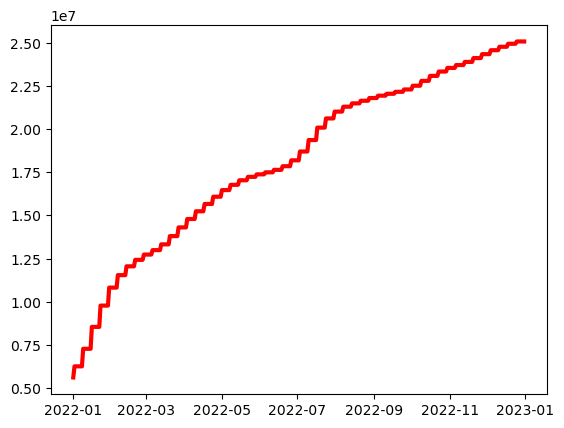

In [75]:
plt.plot(italia_2022_pulito['date'], Italia2022Pulito['total_cases'], 
         color='red', linestyle='-', linewidth=3, label='Casi Totali Cumulativi')

In [76]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

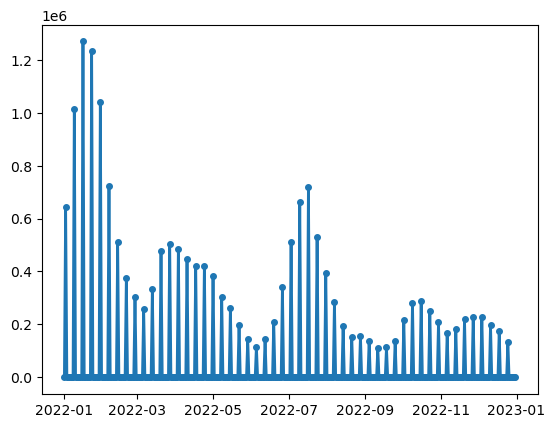

In [77]:
plt.plot(italia_2022_pulito['date'],Italia2022Pulito['new_cases'], 
         color='#1f77b4', linestyle='-', linewidth=2, marker='o', markersize=4, label='Nuovi Casi Registrati')

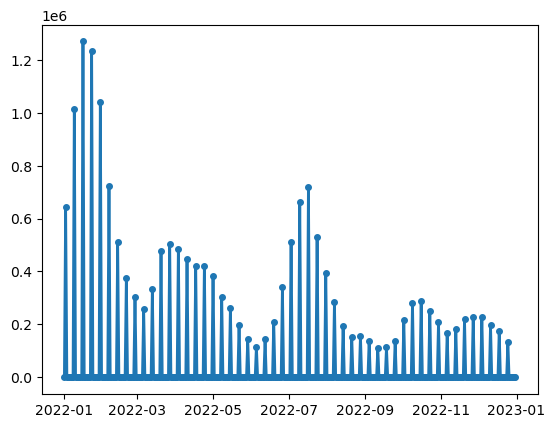

In [77]:
plt.plot(italia_2022_pulito['date'], Italia2022Pulito['new_cases'], 
         color='#1f77b4', linestyle='-', linewidth=2, marker='o', markersize=4, label='Nuovi Casi Registrati')

In [6]:
nazioni = ['Italy', 'Germany', 'France']

In [12]:
CondizioneTempo = (df['date'] >= '2022-05-01') & (df['date'] <= '2023-04-30')
CondizioneNazione = df['location'].isin(nazioni)
CondizioneICU = df['icu_patients'].notna()

In [16]:
plt.figure(figsize=(10, 6), dpi=100)

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [20]:
import seaborn as sns

C:\Users\giova\AppData\Local\Temp\ipykernel_3868\1379189770.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='location', y='icu_patients', data=df,


<Axes: xlabel='location', ylabel='icu_patients'>

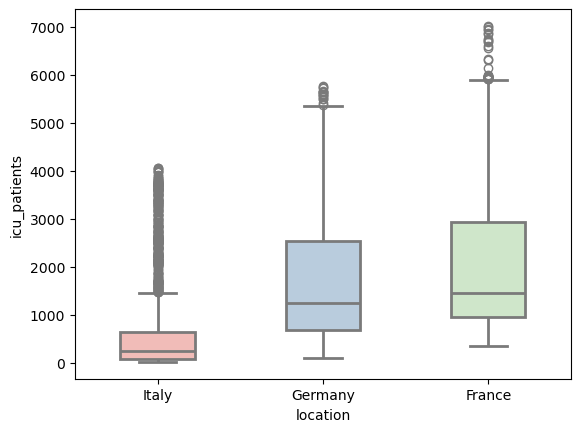

In [21]:
sns.boxplot(x='location', y='icu_patients', data=df, 
            order=nazioni, palette='Pastel1', width=0.45, linewidth=2)

In [1]:
#In Italia troviamo molti casi outlier questo si evince dal grafico rispetto a Francia e Germania che hanno avuto maggior nuemri di casi ma costanti.

In [8]:
location = ["Italy", "Germany", "France", "Spain"]

In [9]:
df_filtrato = df[df["location"].isin(location)].copy()

In [10]:
df_filtrato["date"] = pd.to_datetime(df_filtrato["date"])

In [11]:
df_2021 = df_filtrato[df_filtrato["date"].dt.year == 2021]

In [12]:
null_counts = df_2021["hosp_patients"].isna().sum()

In [13]:
print("Valori nulli in hosp_patients:", null_counts)

Valori nulli in hosp_patients: 365


In [18]:
somma_hosp = df_2021.groupby("location")["hosp_patients"].sum()
print("\nSomma dei pazienti ospedalizzati nel 2021:")
print(somma_hosp)


Somma dei pazienti ospedalizzati nel 2021:
location
France     6008717.0
Germany          0.0
Italy      4419950.0
Spain      2411706.0
Name: hosp_patients, dtype: float64


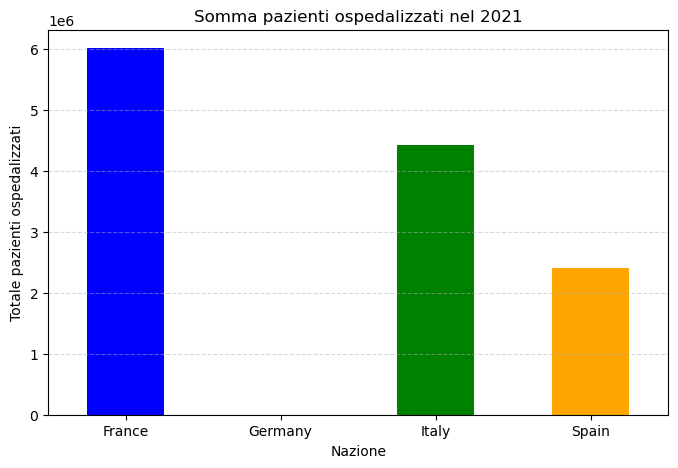

In [23]:
plt.figure(figsize=(8,5))
somma_hosp.plot(kind="bar", color=["blue","red","green","orange"])
plt.title("Somma pazienti ospedalizzati nel 2021")
plt.ylabel("Totale pazienti ospedalizzati")
plt.xlabel("Nazione")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [24]:
#Punto B Dipende dal tipo di analisi che dobbiamo essere e il tipo di dato a disposizione